In [1]:
import numpy as np
import itertools
import math
import matplotlib.pyplot as plt

## Plackett Luce model

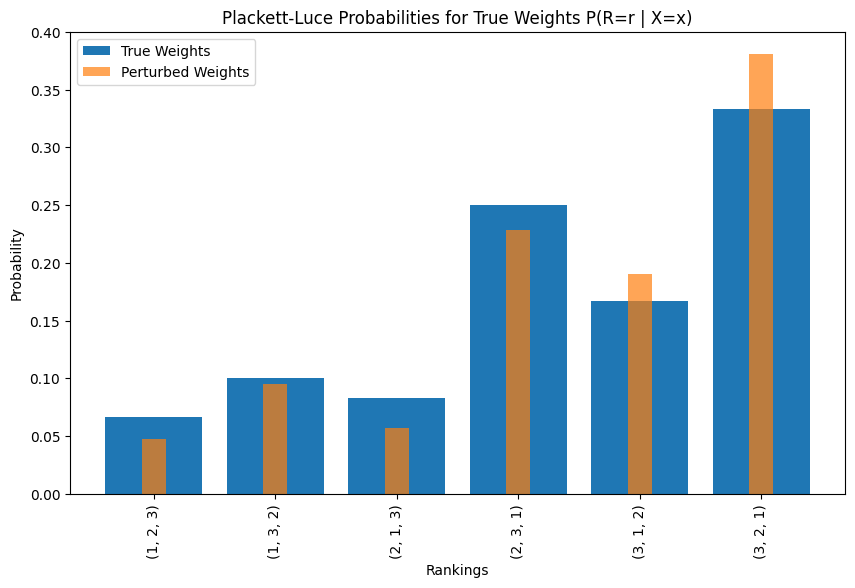

In [2]:
def calculate_pl_probs(weights):
    """Calculate Plackett-Luce probabilities for all rankings given weights.

    Args:
        weights (np.ndarray): Weights for each item, shape (n_items,).
    Returns:
        np.ndarray: Probabilities for each ranking, shape (n_rankings,).
    """
    result_dict = {}
    possible_rankings = itertools.permutations(range(1, len(weights) + 1))
    n_items = len(weights)
    n_rankings = math.factorial(n_items)
    ranking_probs = np.zeros(n_rankings)
    for i, ranking in enumerate(possible_rankings):
        prob = 1.0
        remaining_weights = weights.copy()
        for item in ranking:
            prob *= remaining_weights[item - 1] / remaining_weights.sum()
            remaining_weights[item - 1] = 0  # Remove item from consideration
        ranking_probs[i] = prob
        result_dict[tuple(ranking)] = prob
    return result_dict

true_weights = np.array([1,2,3])
pl_probs_true = calculate_pl_probs(true_weights)



perturbed_weights = np.array([1,2,4])
pl_probs_perturbed = calculate_pl_probs(perturbed_weights)

plt.figure(figsize=(10, 6))
plt.bar(np.array(range(len(pl_probs_true))), list(pl_probs_true.values()), tick_label=[str(k) for k in pl_probs_true.keys()], label='True Weights')
plt.bar(np.array(range(len(pl_probs_perturbed))), list(pl_probs_perturbed.values()), width=0.2, alpha=0.7, label='Perturbed Weights')
plt.xlabel('Rankings')
plt.ylabel('Probability')
plt.title('Plackett-Luce Probabilities for True Weights P(R=r | X=x)')
plt.xticks(rotation=90)
plt.legend()    
plt.show()

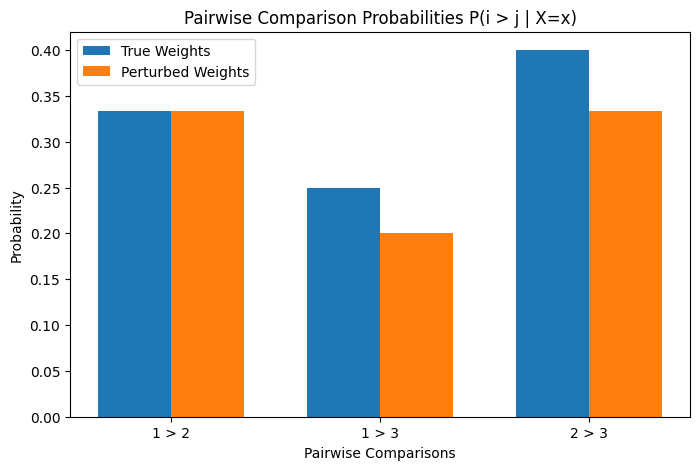

In [3]:
def get_pairwise_probs_from_pl(pl_probs):
    """Marginalize Plackett-Luce probabilities to get pairwise comparison probabilities.
    Args:
        pl_probs (dict): Plackett-Luce probabilities for each ranking.
    Returns:
        dict: Pairwise comparison probabilities.
    """
    pairwise_comparisons = itertools.combinations(range(1, len(next(iter(pl_probs))) + 1), 2)
    pairwise_probs = {}
    for (i, j) in pairwise_comparisons:
        prob_i_over_j = 0.0
        for ranking, prob in pl_probs.items():
            if ranking.index(i) < ranking.index(j):
                prob_i_over_j += prob
        pairwise_probs[(i, j)] = prob_i_over_j
    return pairwise_probs

def get_triple_probs_from_pl(pl_probs):
    """Marginalize Plackett-Luce probabilities to get triple comparison probabilities.
    Args:
        pl_probs (dict): Plackett-Luce probabilities for each ranking.
    Returns:
        dict: Triple comparison probabilities.
    """
    triple_comparisons = itertools.combinations(range(1, len(next(iter(pl_probs))) + 1), 3)
    triple_probs = {}
    for (i, j, k) in triple_comparisons:
        prob_i_over_j_over_k = 0.0
        for ranking, prob in pl_probs.items():
            if ranking.index(i) < ranking.index(j) < ranking.index(k):
                prob_i_over_j_over_k += prob
        triple_probs[(i, j, k)] = prob_i_over_j_over_k
    return triple_probs

true_pairwise_probs = get_pairwise_probs_from_pl(pl_probs_true)
perturbed_pairwise_probs = get_pairwise_probs_from_pl(pl_probs_perturbed)

plt.figure(figsize=(8, 5))
labels = [f"{i} > {j}" for (i, j) in true_pairwise_probs.keys()]
x = np.arange(len(labels))
width = 0.35
plt.bar(x - width/2, list(true_pairwise_probs.values()), width, label='True Weights')
plt.bar(x + width/2, list(perturbed_pairwise_probs.values()), width, label='Perturbed Weights')
plt.xlabel('Pairwise Comparisons')
plt.ylabel('Probability')
plt.title('Pairwise Comparison Probabilities P(i > j | X=x)')
plt.xticks(x, labels)
plt.legend()
plt.show()

In [4]:
x1_weights = 4*np.array([1, 1.5, 1])
pl_probs_x1 = calculate_pl_probs(x1_weights)
x2_weights = 3*np.array([1,2/3,1])
pl_probs_x2 = calculate_pl_probs(x2_weights)

print(x1_weights, x2_weights)

h_model_weights = np.array([1,1,1])
pl_probs_h_model = calculate_pl_probs(h_model_weights)

pl_probs_pairwise_x1 = get_pairwise_probs_from_pl(pl_probs_x1)
pl_probs_pairwise_x2 = get_pairwise_probs_from_pl(pl_probs_x2)
pl_probs_pairwise_h_model = get_pairwise_probs_from_pl(pl_probs_h_model)

for ranking in pl_probs_h_model.keys():
    print(f"Ranking: {ranking}, P(R=r | X=x1): {pl_probs_x1[ranking]:.4f}, P(R=r | X=x2): {pl_probs_x2[ranking]:.4f}, P(R=r | H-model): {pl_probs_h_model[ranking]:.4f}")
    print((pl_probs_x1[ranking]+pl_probs_x2[ranking])/2,  "----", pl_probs_h_model[ranking])
print("------------------")
for ranking in pl_probs_pairwise_h_model.keys():
    print(f"Pairwise: {ranking}, P(i>j | X=x1): {pl_probs_pairwise_x1[ranking]:.4f}, P(i>j | X=x2): {pl_probs_pairwise_x2[ranking]:.4f}, P(i>j | H-model): {pl_probs_pairwise_h_model[ranking]:.4f}")
    print((pl_probs_pairwise_x1[ranking]+pl_probs_pairwise_x2[ranking])/2,  "----", pl_probs_pairwise_h_model[ranking])

[4. 6. 4.] [3. 2. 3.]
Ranking: (1, 2, 3), P(R=r | X=x1): 0.1714, P(R=r | X=x2): 0.1500, P(R=r | H-model): 0.1667
0.1607142857142857 ---- 0.16666666666666666
Ranking: (1, 3, 2), P(R=r | X=x1): 0.1143, P(R=r | X=x2): 0.2250, P(R=r | H-model): 0.1667
0.16964285714285712 ---- 0.16666666666666666
Ranking: (2, 1, 3), P(R=r | X=x1): 0.2143, P(R=r | X=x2): 0.1250, P(R=r | H-model): 0.1667
0.16964285714285715 ---- 0.16666666666666666
Ranking: (2, 3, 1), P(R=r | X=x1): 0.2143, P(R=r | X=x2): 0.1250, P(R=r | H-model): 0.1667
0.16964285714285715 ---- 0.16666666666666666
Ranking: (3, 1, 2), P(R=r | X=x1): 0.1143, P(R=r | X=x2): 0.2250, P(R=r | H-model): 0.1667
0.16964285714285712 ---- 0.16666666666666666
Ranking: (3, 2, 1), P(R=r | X=x1): 0.1714, P(R=r | X=x2): 0.1500, P(R=r | H-model): 0.1667
0.1607142857142857 ---- 0.16666666666666666
------------------
Pairwise: (1, 2), P(i>j | X=x1): 0.4000, P(i>j | X=x2): 0.6000, P(i>j | H-model): 0.5000
0.5 ---- 0.5
Pairwise: (1, 3), P(i>j | X=x1): 0.5000, P(

In [5]:
# With this procedure, the pairwise probabilities are flipped... mhmmm
t1_weights = np.array([1, 2, 1/2])
pl_probs_t1 = calculate_pl_probs(t1_weights)
t2_weights = np.array([2, 1/2, 1])
pl_probs_t2 = calculate_pl_probs(t2_weights)
t3_weights = np.array([2, 1, 1/2])
pl_probs_t3 = calculate_pl_probs(t3_weights)
t4_weights = np.array([1, 1/2, 2])
pl_probs_t4 = calculate_pl_probs(t4_weights)
t5_weights = np.array([1/2, 1, 2])
pl_probs_t5 = calculate_pl_probs(t5_weights)
t6_weights = np.array([1/2, 2, 1])
pl_probs_t6 = calculate_pl_probs(t6_weights)

t7_weights = np.array([1, 1, 1])
pl_probs_t7 = calculate_pl_probs(t7_weights)

pl_pairwise_t1 = get_pairwise_probs_from_pl(pl_probs_t1)
pl_pairwise_t2 = get_pairwise_probs_from_pl(pl_probs_t2)
pl_pairwise_t3 = get_pairwise_probs_from_pl(pl_probs_t3)
pl_pairwise_t4 = get_pairwise_probs_from_pl(pl_probs_t4)
pl_pairwise_t5 = get_pairwise_probs_from_pl(pl_probs_t5)
pl_pairwise_t6 = get_pairwise_probs_from_pl(pl_probs_t6)
pl_pairwise_t7 = get_pairwise_probs_from_pl(pl_probs_t7)

for ranking in pl_probs_t1.keys():
    print(f"Ranking: {ranking}, P(R=r | X=x1): {pl_probs_t1[ranking]:.4f}, P(R=r | X=x2): {pl_probs_t2[ranking]:.4f}, P(R=r | X=x3): {pl_probs_t3[ranking]:.4f}, P(R=r | X=x4): {pl_probs_t4[ranking]:.4f}, P(R=r | X=x5): {pl_probs_t5[ranking]:.4f}, P(R=r | X=x6): {pl_probs_t6[ranking]:.4f}")
    print((pl_probs_t1[ranking] + pl_probs_t2[ranking] + pl_probs_t3[ranking] + pl_probs_t4[ranking] + pl_probs_t5[ranking] + pl_probs_t6[ranking])/6 ,  "----", pl_probs_t7[ranking])

for ranking in pl_pairwise_t1.keys():
    print(f"Ranking: {ranking}, P(R=r | X=x1): {pl_pairwise_t1[ranking]:.4f}, P(R=r | X=x2): {pl_pairwise_t2[ranking]:.4f}, P(R=r | X=x3): {pl_pairwise_t3[ranking]:.4f}, P(R=r | X=x4): {pl_pairwise_t4[ranking]:.4f}, P(R=r | X=x5): {pl_pairwise_t5[ranking]:.4f}, P(R=r | X=x6): {pl_pairwise_t6[ranking]:.4f}")
    print((pl_pairwise_t1[ranking] + pl_pairwise_t2[ranking] + pl_pairwise_t3[ranking] + pl_pairwise_t4[ranking] + pl_pairwise_t5[ranking] + pl_pairwise_t6[ranking])/6 ,  "----", pl_pairwise_t7[ranking])

Ranking: (1, 2, 3), P(R=r | X=x1): 0.2286, P(R=r | X=x2): 0.1905, P(R=r | X=x3): 0.3810, P(R=r | X=x4): 0.0571, P(R=r | X=x5): 0.0476, P(R=r | X=x6): 0.0952
0.16666666666666666 ---- 0.16666666666666666
Ranking: (1, 3, 2), P(R=r | X=x1): 0.0571, P(R=r | X=x2): 0.3810, P(R=r | X=x3): 0.1905, P(R=r | X=x4): 0.2286, P(R=r | X=x5): 0.0952, P(R=r | X=x6): 0.0476
0.16666666666666666 ---- 0.16666666666666666
Ranking: (2, 1, 3), P(R=r | X=x1): 0.3810, P(R=r | X=x2): 0.0952, P(R=r | X=x3): 0.2286, P(R=r | X=x4): 0.0476, P(R=r | X=x5): 0.0571, P(R=r | X=x6): 0.1905
0.16666666666666666 ---- 0.16666666666666666
Ranking: (2, 3, 1), P(R=r | X=x1): 0.1905, P(R=r | X=x2): 0.0476, P(R=r | X=x3): 0.0571, P(R=r | X=x4): 0.0952, P(R=r | X=x5): 0.2286, P(R=r | X=x6): 0.3810
0.16666666666666666 ---- 0.16666666666666666
Ranking: (3, 1, 2), P(R=r | X=x1): 0.0476, P(R=r | X=x2): 0.2286, P(R=r | X=x3): 0.0952, P(R=r | X=x4): 0.3810, P(R=r | X=x5): 0.1905, P(R=r | X=x6): 0.0571
0.16666666666666666 ---- 0.16666666

In [6]:
# With this procedure, the pairwise probabilities are flipped... mhmmm
t1_weights = np.array([1, 2, 1 / 2])
pl_probs_t1 = calculate_pl_probs(t1_weights)
t2_weights = np.array([1, 1/2, 2])
pl_probs_t2 = calculate_pl_probs(t2_weights)
t3_weights = np.array([1/2, 1, 2])
pl_probs_t3 = calculate_pl_probs(t3_weights)

t7_weights = np.array([1, 1.25, 2])
pl_probs_t7 = calculate_pl_probs(t7_weights)

pl_pairwise_t1 = get_pairwise_probs_from_pl(pl_probs_t1)
pl_pairwise_t2 = get_pairwise_probs_from_pl(pl_probs_t2)
pl_pairwise_t3 = get_pairwise_probs_from_pl(pl_probs_t3)

pl_pairwise_t7 = get_pairwise_probs_from_pl(pl_probs_t7)

for ranking in pl_probs_t1.keys():
    print(
        f"Ranking: {ranking}, P(R=r | X=x1): {pl_probs_t1[ranking]:.4f}, P(R=r | X=x2): {pl_probs_t2[ranking]:.4f}, P(R=r | X=x3): {pl_probs_t3[ranking]:.4f}"
    )
    print(
        (
            pl_probs_t1[ranking]
            + pl_probs_t2[ranking]
        ) / 2,
        "----",
        pl_probs_t7[ranking],
    )

for ranking in pl_pairwise_t1.keys():
    print(
        f"Ranking: {ranking}, P(R=r | X=x1): {pl_pairwise_t1[ranking]:.4f}, P(R=r | X=x2): {pl_pairwise_t2[ranking]:.4f}, P(R=r | X=x3): {pl_pairwise_t3[ranking]:.4f}"
    )
    print(
        (
            pl_pairwise_t1[ranking]
            + pl_pairwise_t2[ranking]
        ) / 2,
        "----",
        pl_pairwise_t7[ranking],
    )

Ranking: (1, 2, 3), P(R=r | X=x1): 0.2286, P(R=r | X=x2): 0.0571, P(R=r | X=x3): 0.0476
0.14285714285714285 ---- 0.09049773755656108
Ranking: (1, 3, 2), P(R=r | X=x1): 0.0571, P(R=r | X=x2): 0.2286, P(R=r | X=x3): 0.0952
0.14285714285714285 ---- 0.14479638009049775
Ranking: (2, 1, 3), P(R=r | X=x1): 0.3810, P(R=r | X=x2): 0.0476, P(R=r | X=x3): 0.0571
0.21428571428571427 ---- 0.09803921568627451
Ranking: (2, 3, 1), P(R=r | X=x1): 0.1905, P(R=r | X=x2): 0.0952, P(R=r | X=x3): 0.2286
0.14285714285714285 ---- 0.19607843137254902
Ranking: (3, 1, 2), P(R=r | X=x1): 0.0476, P(R=r | X=x2): 0.3810, P(R=r | X=x3): 0.1905
0.21428571428571427 ---- 0.2091503267973856
Ranking: (3, 2, 1), P(R=r | X=x1): 0.0952, P(R=r | X=x2): 0.1905, P(R=r | X=x3): 0.3810
0.14285714285714285 ---- 0.26143790849673204
Ranking: (1, 2), P(R=r | X=x1): 0.3333, P(R=r | X=x2): 0.6667, P(R=r | X=x3): 0.3333
0.5 ---- 0.4444444444444444
Ranking: (1, 3), P(R=r | X=x1): 0.6667, P(R=r | X=x2): 0.3333, P(R=r | X=x3): 0.2000
0.5 -

In [7]:
for ranking in pl_pairwise_t3.keys():
    print(
        f"Pairwise: {ranking}, P(i > j | X=x1): {pl_pairwise_t1[ranking]:.4f}, P(i > j | X=x2): {pl_pairwise_t2[ranking]:.4f}, P(i > j | H-model): {pl_pairwise_t3[ranking]:.4f}"
    )
    print(
        (pl_pairwise_t1[ranking] + pl_pairwise_t2[ranking]) / 2,
        "----",
        pl_pairwise_t3[ranking],
    )

Pairwise: (1, 2), P(i > j | X=x1): 0.3333, P(i > j | X=x2): 0.6667, P(i > j | H-model): 0.3333
0.5 ---- 0.3333333333333333
Pairwise: (1, 3), P(i > j | X=x1): 0.6667, P(i > j | X=x2): 0.3333, P(i > j | H-model): 0.2000
0.5 ---- 0.19999999999999998
Pairwise: (2, 3), P(i > j | X=x1): 0.8000, P(i > j | X=x2): 0.2000, P(i > j | H-model): 0.3333
0.49999999999999994 ---- 0.3333333333333333


In [8]:
(
    t1_weights[0] * t1_weights[1]
    + t1_weights[1] * t1_weights[2]
    + t1_weights[0] * t1_weights[2]
) / ((t1_weights[0] + t1_weights[1] + t1_weights[2]) * (t1_weights[1] * t1_weights[2]))

np.float64(1.0)

In [9]:
pl_probs_t1[(1,2,3)] == pl_probs_t2[(3,1,2)] * (t1_weights[0]*t1_weights[1]  + t1_weights[1]*t1_weights[2] + t1_weights[0]*t1_weights[2]) / ((t1_weights[0] + t1_weights[1] + t1_weights[2]) * (t1_weights[1]*t1_weights[2]))

np.False_

In [10]:
x1_weights =  np.array([0.6, 0.5, 0.4])
pl_probs_x1 = calculate_pl_probs(x1_weights)
x2_weights = np.array([0.4, 0.5, 0.6])
pl_probs_x2 = calculate_pl_probs(x2_weights)

print(x1_weights, x2_weights)

h_model_weights = np.array([1, 1, 1])
pl_probs_h_model = calculate_pl_probs(h_model_weights)

for ranking in pl_probs_h_model.keys():
    print(f"Ranking: {ranking}, P(R=r | X=x1): {pl_probs_x1[ranking]:.4f}, P(R=r | X=x2): {pl_probs_x2[ranking]:.4f}, P(R=r | H-model): {pl_probs_h_model[ranking]:.4f}")
    print(f"{(pl_probs_x1[ranking] + pl_probs_x2[ranking]) / 2:.4f} ---- {pl_probs_h_model[ranking]:.4f}")

[0.6 0.5 0.4] [0.4 0.5 0.6]
Ranking: (1, 2, 3), P(R=r | X=x1): 0.2222, P(R=r | X=x2): 0.1212, P(R=r | H-model): 0.1667
0.1717 ---- 0.1667
Ranking: (1, 3, 2), P(R=r | X=x1): 0.1778, P(R=r | X=x2): 0.1455, P(R=r | H-model): 0.1667
0.1616 ---- 0.1667
Ranking: (2, 1, 3), P(R=r | X=x1): 0.2000, P(R=r | X=x2): 0.1333, P(R=r | H-model): 0.1667
0.1667 ---- 0.1667
Ranking: (2, 3, 1), P(R=r | X=x1): 0.1333, P(R=r | X=x2): 0.2000, P(R=r | H-model): 0.1667
0.1667 ---- 0.1667
Ranking: (3, 1, 2), P(R=r | X=x1): 0.1455, P(R=r | X=x2): 0.1778, P(R=r | H-model): 0.1667
0.1616 ---- 0.1667
Ranking: (3, 2, 1), P(R=r | X=x1): 0.1212, P(R=r | X=x2): 0.2222, P(R=r | H-model): 0.1667
0.1717 ---- 0.1667


In [25]:
print(
    "Prob of 1 being first: ",
    pl_probs_x1[(1, 2, 3)] + pl_probs_x1[(1, 3, 2)],
    pl_probs_x2[(1, 2, 3)] + pl_probs_x2[(1, 3, 2)],
    (pl_probs_x1[(1, 2, 3)] + pl_probs_x1[(1, 3, 2)] +
    pl_probs_x2[(1, 2, 3)] + pl_probs_x2[(1, 3, 2)])/2,
    pl_probs_h_model[(1, 2, 3)] + pl_probs_h_model[(1, 3, 2)],
)
print("Prob of 2 being first: ",
      pl_probs_x1[(2,1,3)] + pl_probs_x1[(2,3,1)],
      pl_probs_x2[(2,1,3)] + pl_probs_x2[(2,3,1)],
      (pl_probs_x1[(2,1,3)] + pl_probs_x1[(2,3,1)] +
      pl_probs_x2[(2,1,3)] + pl_probs_x2[(2,3,1)])/2,
      pl_probs_h_model[(2,1,3)] + pl_probs_h_model[(2,3,1)])
print(
    "Prob of 3 being first: ",
    pl_probs_x1[(3, 1, 2)] + pl_probs_x1[(3, 2, 1)],
    pl_probs_x2[(3, 1, 2)] + pl_probs_x2[(3, 2, 1)],
    (pl_probs_x1[(3, 1, 2)] + pl_probs_x1[(3, 2, 1)] +
    pl_probs_x2[(3, 1, 2)] + pl_probs_x2[(3, 2, 1)])/2,
    pl_probs_h_model[(3, 1, 2)] + pl_probs_h_model[(3, 2, 1)],
)

Prob of 1 being first:  0.4 0.26666666666666666 0.33333333333333337 0.3333333333333333
Prob of 2 being first:  0.3333333333333333 0.3333333333333333 0.3333333333333333 0.3333333333333333
Prob of 3 being first:  0.26666666666666666 0.4 0.3333333333333333 0.3333333333333333


## Mallows Model

In [30]:
def mallows_normalization_constant(n_items, dispersion):
    constant = 1.0
    for j in range(1, n_items + 1):
        constant *= 1 + sum([dispersion**k for k in range(1, j)])
    return 1 / constant


def calculate_mallows_probs_kendall(central_ranking, phi):
    """Calculate Mallows model probabilities for all rankings given central ranking and phi.

    Args:
        central_ranking (list): Central ranking as a list of item indices.
        phi (float): Dispersion parameter, 0 < phi <= 1.
    Returns:
        dict: Probabilities for each ranking.
    """
    result_dict = {}
    possible_rankings = itertools.permutations(range(1, len(central_ranking) + 1))
    n_items = len(central_ranking)
    n_rankings = math.factorial(n_items)
    ranking_probs = np.zeros(n_rankings)
    for i, ranking in enumerate(possible_rankings):
        # Calculate Kendall tau distance
        distance = sum(
            1
            for a, b in itertools.combinations(range(n_items), 2)
            if (central_ranking.index(a + 1) - central_ranking.index(b + 1)) * (ranking.index(a + 1) - ranking.index(b + 1)) < 0
        )
        prob = (phi**distance) * mallows_normalization_constant(n_items, phi)
        ranking_probs[i] = prob
        result_dict[tuple(ranking)] = prob
    return result_dict


def calculate_mallows_probs_spearman_rho(central_ranking, phi):
    """Calculate Mallows model probabilities for all rankings given central ranking and phi.

    Args:
        central_ranking (list): Central ranking as a list of item indices.
        phi (float): Dispersion parameter, 0 < phi <= 1.
    Returns:
        dict: Probabilities for each ranking.
    """
    result_dict = {}
    possible_rankings = itertools.permutations(range(1, len(central_ranking) + 1))
    n_items = len(central_ranking)
    n_rankings = math.factorial(n_items)
    ranking_probs = np.zeros(n_rankings)
    for i, ranking in enumerate(possible_rankings):
        # Calculate Spearman Rho distance
        distance = sum(
            [(central_ranking[k] - ranking[k])**2 for k in range(n_items)]
        )
        prob = (phi**distance) * mallows_normalization_constant(n_items, phi)
        ranking_probs[i] = prob
        result_dict[tuple(ranking)] = prob
    return result_dict


def calculate_mallows_probs_hamming(central_ranking, phi):
    """Calculate Mallows model probabilities for all rankings given central ranking and phi.

    Args:
        central_ranking (list): Central ranking as a list of item indices.
        phi (float): Dispersion parameter, 0 < phi <= 1.
    Returns:
        dict: Probabilities for each ranking.
    """
    result_dict = {}
    possible_rankings = itertools.permutations(range(1, len(central_ranking) + 1))
    n_items = len(central_ranking)
    n_rankings = math.factorial(n_items)
    ranking_probs = np.zeros(n_rankings)
    for i, ranking in enumerate(possible_rankings):
        # Calculate Ulam distance
        distance = sum(central_ranking[k] != ranking[k] for k in range(n_items))
        prob = (phi**distance) * mallows_normalization_constant(n_items, phi)
        ranking_probs[i] = prob
        result_dict[tuple(ranking)] = prob
    return result_dict


#h_central_ranking = calculate_mallows_probs_kendall([1, 2, 3], phi=1)
h_central_ranking = calculate_mallows_probs_kendall([1, 2, 3], phi=1)
for ranking in h_central_ranking.keys():
    print(f"Ranking: {ranking}, P(R=r | H-model): {h_central_ranking[ranking]:.4f}")

x1_central_ranking = calculate_mallows_probs_kendall([1, 2, 3], phi=0.5)
#x1_central_ranking = calculate_mallows_probs_kendall([1, 2, 3], phi=0.5)
#x2_central_ranking = calculate_mallows_probs_kendall([3, 2, 1], phi=0.5)
x2_central_ranking = calculate_mallows_probs_kendall([3,2,1], phi=0.5)

Ranking: (1, 2, 3), P(R=r | H-model): 0.1667
Ranking: (1, 3, 2), P(R=r | H-model): 0.1667
Ranking: (2, 1, 3), P(R=r | H-model): 0.1667
Ranking: (2, 3, 1), P(R=r | H-model): 0.1667
Ranking: (3, 1, 2), P(R=r | H-model): 0.1667
Ranking: (3, 2, 1), P(R=r | H-model): 0.1667


In [31]:
sum(x1_central_ranking.values())

1.0

In [32]:
for ranking in x1_central_ranking.keys():
    print(
        f"Ranking: {ranking}, P(R=r | X=x1): {x1_central_ranking[ranking]:.4f}, P(R=r | X=x2): {x2_central_ranking[ranking]:.4f}, P(R=r | H-model): {h_central_ranking[ranking]:.4f}"
    )
    print(f"{(x1_central_ranking[ranking] + x2_central_ranking[ranking]) / 2:.4f} ---- {h_central_ranking[ranking]:.4f}"
    )

Ranking: (1, 2, 3), P(R=r | X=x1): 0.3810, P(R=r | X=x2): 0.0476, P(R=r | H-model): 0.1667
0.2143 ---- 0.1667
Ranking: (1, 3, 2), P(R=r | X=x1): 0.1905, P(R=r | X=x2): 0.0952, P(R=r | H-model): 0.1667
0.1429 ---- 0.1667
Ranking: (2, 1, 3), P(R=r | X=x1): 0.1905, P(R=r | X=x2): 0.0952, P(R=r | H-model): 0.1667
0.1429 ---- 0.1667
Ranking: (2, 3, 1), P(R=r | X=x1): 0.0952, P(R=r | X=x2): 0.1905, P(R=r | H-model): 0.1667
0.1429 ---- 0.1667
Ranking: (3, 1, 2), P(R=r | X=x1): 0.0952, P(R=r | X=x2): 0.1905, P(R=r | H-model): 0.1667
0.1429 ---- 0.1667
Ranking: (3, 2, 1), P(R=r | X=x1): 0.0476, P(R=r | X=x2): 0.3810, P(R=r | H-model): 0.1667
0.2143 ---- 0.1667


In [33]:
print("------------------")
print(
    "Prob of 1 being first:",
    x1_central_ranking[(1, 2, 3)] + x1_central_ranking[(1, 3, 2)],
    x2_central_ranking[(1, 2, 3)] + x2_central_ranking[(1, 3, 2)],
    (x1_central_ranking[(1, 2, 3)] + x2_central_ranking[(1, 2, 3)] + x1_central_ranking[(1, 3, 2)] + x2_central_ranking[(1, 3, 2)])/2,
    (h_central_ranking[(1, 2, 3)] + h_central_ranking[(1, 3, 2)])
)
print("------------------")
print(
    "Prob of 2 being first:",
    x1_central_ranking[(2, 1, 3)] + x1_central_ranking[(2, 3, 1)],
    x2_central_ranking[(2, 1, 3)] + x2_central_ranking[(2, 3, 1)],
    (x1_central_ranking[(2, 1, 3)] + x2_central_ranking[(2, 1, 3)] + x1_central_ranking[(2, 3, 1)] + x2_central_ranking[(2, 3, 1)])/2,
    (h_central_ranking[(2, 1, 3)] + h_central_ranking[(2, 3, 1)])
)
print("------------------")
print(
    "Prob of 3 being first:",
    x1_central_ranking[(3, 1, 2)] + x1_central_ranking[(3, 2, 1)],
    x2_central_ranking[(3, 1, 2)] + x2_central_ranking[(3, 2, 1)],
    (x1_central_ranking[(3, 1, 2)] + x2_central_ranking[(3, 1, 2)] + x1_central_ranking[(3, 2, 1)] + x2_central_ranking[(3, 2, 1)])/2,
    (h_central_ranking[(3, 1, 2)] + h_central_ranking[(3, 2, 1)]),
)

------------------
Prob of 1 being first: 0.5714285714285714 0.14285714285714285 0.35714285714285715 0.3333333333333333
------------------
Prob of 2 being first: 0.2857142857142857 0.2857142857142857 0.2857142857142857 0.3333333333333333
------------------
Prob of 3 being first: 0.14285714285714285 0.5714285714285714 0.3571428571428571 0.3333333333333333


In [15]:
x1_mallow_pairwise = get_pairwise_probs_from_pl(x1_central_ranking)
x2_mallow_pairwise = get_pairwise_probs_from_pl(x2_central_ranking) 
h_mallow_pairwise = get_pairwise_probs_from_pl(h_central_ranking)

for ranking in x1_mallow_pairwise.keys():
    print(f"Pairwise: {ranking}, P(i > j | X=x1): {x1_mallow_pairwise[ranking]:.4f}, P(i > j | X=x2): {x2_mallow_pairwise[ranking]:.4f}, P(i > j | H-model): {h_mallow_pairwise[ranking]:.4f}")
    print(f"{(x1_mallow_pairwise[ranking] + x2_mallow_pairwise[ranking]) / 2:.4f} ---- {h_mallow_pairwise[ranking]:.4f}")

Pairwise: (1, 2), P(i > j | X=x1): 0.7619, P(i > j | X=x2): 0.3333, P(i > j | H-model): 0.5714
0.5476 ---- 0.5714
Pairwise: (1, 3), P(i > j | X=x1): 0.6667, P(i > j | X=x2): 0.6667, P(i > j | H-model): 0.6178
0.6667 ---- 0.6178
Pairwise: (2, 3), P(i > j | X=x1): 0.3333, P(i > j | X=x2): 0.7619, P(i > j | H-model): 0.5714
0.5476 ---- 0.5714


### Hamming Distance

In [16]:
h_central_ranking = calculate_mallows_probs_hamming([1, 2, 3], phi=1)
for ranking in h_central_ranking.keys():
    print(f"Ranking: {ranking}, P(R=r | H-model): {h_central_ranking[ranking]:.4f}")

x1_central_ranking = calculate_mallows_probs_hamming([1, 2, 3], phi=0.5)
x2_central_ranking = calculate_mallows_probs_hamming([3, 2, 1], phi=0.5)

Ranking: (1, 2, 3), P(R=r | H-model): 0.1667
Ranking: (1, 3, 2), P(R=r | H-model): 0.1667
Ranking: (2, 1, 3), P(R=r | H-model): 0.1667
Ranking: (2, 3, 1), P(R=r | H-model): 0.1667
Ranking: (3, 1, 2), P(R=r | H-model): 0.1667
Ranking: (3, 2, 1), P(R=r | H-model): 0.1667


In [17]:
sum(x1_central_ranking.values())

0.761904761904762

In [18]:
for ranking in x1_central_ranking.keys():
    print(
        f"Ranking: {ranking}, P(R=r | X=x1): {x1_central_ranking[ranking]:.4f}, P(R=r | X=x2): {x2_central_ranking[ranking]:.4f}, P(R=r | H-model): {h_central_ranking[ranking]:.4f}"
    )
    print(
        (x1_central_ranking[ranking] + x2_central_ranking[ranking]) / 2,
        "----",
        h_central_ranking[ranking],
    )

Ranking: (1, 2, 3), P(R=r | X=x1): 0.3810, P(R=r | X=x2): 0.0952, P(R=r | H-model): 0.1667
0.23809523809523808 ---- 0.16666666666666666
Ranking: (1, 3, 2), P(R=r | X=x1): 0.0952, P(R=r | X=x2): 0.0476, P(R=r | H-model): 0.1667
0.07142857142857142 ---- 0.16666666666666666
Ranking: (2, 1, 3), P(R=r | X=x1): 0.0952, P(R=r | X=x2): 0.0476, P(R=r | H-model): 0.1667
0.07142857142857142 ---- 0.16666666666666666
Ranking: (2, 3, 1), P(R=r | X=x1): 0.0476, P(R=r | X=x2): 0.0952, P(R=r | H-model): 0.1667
0.07142857142857142 ---- 0.16666666666666666
Ranking: (3, 1, 2), P(R=r | X=x1): 0.0476, P(R=r | X=x2): 0.0952, P(R=r | H-model): 0.1667
0.07142857142857142 ---- 0.16666666666666666
Ranking: (3, 2, 1), P(R=r | X=x1): 0.0952, P(R=r | X=x2): 0.3810, P(R=r | H-model): 0.1667
0.23809523809523808 ---- 0.16666666666666666


In [19]:
x1_mallow_pairwise = get_pairwise_probs_from_pl(x1_central_ranking)
x2_mallow_pairwise = get_pairwise_probs_from_pl(x2_central_ranking)
h_mallow_pairwise = get_pairwise_probs_from_pl(h_central_ranking)

for ranking in x1_mallow_pairwise.keys():
    print(
        f"Pairwise: {ranking}, P(i > j | X=x1): {x1_mallow_pairwise[ranking]:.4f}, P(i > j | X=x2): {x2_mallow_pairwise[ranking]:.4f}, P(i > j | H-model): {h_mallow_pairwise[ranking]:.4f}"
    )

Pairwise: (1, 2), P(i > j | X=x1): 0.5238, P(i > j | X=x2): 0.2381, P(i > j | H-model): 0.5000
Pairwise: (1, 3), P(i > j | X=x1): 0.5714, P(i > j | X=x2): 0.1905, P(i > j | H-model): 0.5000
Pairwise: (2, 3), P(i > j | X=x1): 0.5238, P(i > j | X=x2): 0.2381, P(i > j | H-model): 0.5000


In [20]:
h_central_ranking = calculate_mallows_probs_spearman_rho([1, 2, 3], phi=1)
for ranking in h_central_ranking.keys():
    print(f"Ranking: {ranking}, P(R=r | H-model): {h_central_ranking[ranking]:.4f}")

x1_central_ranking = calculate_mallows_probs_spearman_rho([1, 2, 3], phi=0.5)
x2_central_ranking = calculate_mallows_probs_spearman_rho([3, 2, 1], phi=0.5)

Ranking: (1, 2, 3), P(R=r | H-model): 0.1667
Ranking: (1, 3, 2), P(R=r | H-model): 0.1667
Ranking: (2, 1, 3), P(R=r | H-model): 0.1667
Ranking: (2, 3, 1), P(R=r | H-model): 0.1667
Ranking: (3, 1, 2), P(R=r | H-model): 0.1667
Ranking: (3, 2, 1), P(R=r | H-model): 0.1667


### Spearman Rho

In [21]:
h_central_ranking = calculate_mallows_probs_spearman_rho([1, 2, 3], phi=1)
for ranking in h_central_ranking.keys():
    print(f"Ranking: {ranking}, P(R=r | H-model): {h_central_ranking[ranking]:.4f}")

x1_central_ranking = calculate_mallows_probs_spearman_rho([1, 2, 3], phi=0.5)
x2_central_ranking = calculate_mallows_probs_spearman_rho([3, 2, 1], phi=0.5)

Ranking: (1, 2, 3), P(R=r | H-model): 0.1667
Ranking: (1, 3, 2), P(R=r | H-model): 0.1667
Ranking: (2, 1, 3), P(R=r | H-model): 0.1667
Ranking: (2, 3, 1), P(R=r | H-model): 0.1667
Ranking: (3, 1, 2), P(R=r | H-model): 0.1667
Ranking: (3, 2, 1), P(R=r | H-model): 0.1667


In [22]:
sum(x1_central_ranking.values())

0.5848214285714285